In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from FHO_FR_VV.k_vv_mm import k_vv_mm
from FHO_FR_VV.particles_data import CO, N2, O2

PARTICLE_MAP = {"N2": N2, "O2": O2, "CO": CO}


def get_particle(name: str):
    if name not in PARTICLE_MAP:
        raise ValueError(f"Неизвестная молекула: {name}. Допустимо: {list(PARTICLE_MAP)}")
    return PARTICLE_MAP[name]


def mape_loss(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)


def k_model_poly(T, *coeffs):
    x = np.power(np.asarray(T, dtype=float), -1.0 / 3.0)
    out = np.zeros_like(x, dtype=float)
    for k, c in enumerate(coeffs):
        out += float(c) * np.power(x, k)
    return out


def fit_poly(df: pd.DataFrame):
    """Как в `regression.ipynb`: для каждой числовой колонки после `T` подбирает степень 3…6 параметров LM + MAPE."""
    params_arr = []
    pred_df = pd.DataFrame(index=df.index)
    for col_i in range(1, df.shape[1]):
        coeffs = None
        pred = np.zeros(len(df))
        best_mape = np.inf

        series = pd.to_numeric(df.iloc[:, col_i], errors="coerce")
        mask = np.isfinite(series.values) & (series.values > 0)
        T_col = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        T_valid = T_col.values[mask]
        y_valid = series.values[mask]

        if len(T_valid) < 4:
            raise ValueError("Недостаточно положительных точек для полинома.")

        y_log = np.log(y_valid)
        norm_factor = float(np.max(np.abs(y_log)))
        if norm_factor == 0:
            norm_factor = 1.0
        y_norm = y_log / norm_factor

        for coeff_num in range(4, 8):
            p0 = np.ones(coeff_num)
            params, _ = curve_fit(
                k_model_poly,
                T_valid,
                y_norm,
                p0=p0,
                method="lm",
                maxfev=40000,
            )

            params1 = params * norm_factor
            y_pred_log_full = k_model_poly(T_col.values.astype(float), *params1)
            k_pred_full = np.exp(y_pred_log_full)

            valid_pred = np.isfinite(k_pred_full) & mask
            if not np.any(valid_pred):
                continue
            mape_poly = mape_loss(series.values[valid_pred], k_pred_full[valid_pred])

            if mape_poly < best_mape:
                best_mape = mape_poly
                coeffs = params1.astype(float)
                pred = k_pred_full

        if coeffs is None:
            raise RuntimeError("curve_fit не сработала ни для одного порядка.")

        params_arr.append(coeffs)
        pred_df[col_i - 1] = pred

    return params_arr, pred_df


def transitions_for_indices(v_max: int, v: int, vp: int) -> list[tuple[int, int, int, int]]:
    """Четыре физических класса переходов из вашего блока по `(v,v')`."""
    transitions: list[tuple[int, int, int, int]] = []
    if v + 1 <= v_max and vp + 1 <= v_max:
        transitions.append((v + 1, v, vp, vp + 1))
    if v - 1 >= 0 and vp - 1 >= 0:
        transitions.append((v - 1, v, vp, vp - 1))
    if v - 1 >= 0 and vp + 1 <= v_max:
        transitions.append((v, v - 1, vp, vp + 1))
    if v + 1 <= v_max and vp - 1 >= 0:
        transitions.append((v, v + 1, vp, vp - 1))
    return transitions


def run_generation_and_fit(
    particle1_name: str,
    particle2_name: str,
    *,
    v_max: int = 6,
    n_points: int = 30,
    T_min: float = 300.0,
    T_max: float = 10_000.0,
    max_plot_transitions: int = 6,
) -> tuple[str, str]:
    p1 = get_particle(particle1_name)
    p2 = get_particle(particle2_name)

    stem = f"{particle1_name}_{particle2_name}"
    dataset_dir = Path("dataset")
    regression_coefficients_dir = Path("regression_coefficients")
    figures_dir = Path("figures")
    dataset_dir.mkdir(parents=True, exist_ok=True)
    regression_coefficients_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)
    csv_dataset = str(dataset_dir / f"{stem}_dataset.csv")
    csv_coefs = str(regression_coefficients_dir / f"{stem}_regression_coefs.csv")

    T_data = np.sort(np.linspace(T_min, T_max, n_points).astype(float))

    seen_quad: set[tuple[int, int, int, int]] = set()
    dataset_rows: list[dict] = []

    coef_rows_success: list[dict] = []
    samples_for_plot: list[tuple[tuple[int, int, int, int], pd.DataFrame, np.ndarray]] = []

    for v in range(v_max + 1):
        for vp in range(v_max + 1):
            for quad in transitions_for_indices(v_max, v, vp):
                if quad in seen_quad:
                    continue
                seen_quad.add(quad)

                v1, v2, v1p, v2p = quad
                ks = []
                for T in T_data:
                    k = float(k_vv_mm(p1, p2, v1, v2, v1p, v2p, float(T)))
                    ks.append(k)

                ks_arr = np.asarray(ks, dtype=float)

                for Ti, kv in zip(T_data, ks_arr):
                    dataset_rows.append(
                        {
                            "T": float(Ti),
                            "i1": int(v1),
                            "f1": int(v2),
                            "i2": int(v1p),
                            "f2": int(v2p),
                            "k_VV": float(kv),
                        }
                    )

                if np.any(ks_arr <= 0) or np.any(~np.isfinite(ks_arr)):
                    continue

                df_k = pd.DataFrame({"T": T_data, "k": ks_arr})
                coeffs_pack, pred_df = fit_poly(df_k)
                coef_vec = coeffs_pack[0]

                row = {"i1": int(v1), "f1": int(v2), "i2": int(v1p), "f2": int(v2p)}
                for j, aj in enumerate(coef_vec):
                    row[f"a_{j}"] = float(aj)
                coef_rows_success.append(row)

                if len(samples_for_plot) < max_plot_transitions:
                    pred_series = pd.to_numeric(pred_df.iloc[:, 0], errors="coerce").values
                    samples_for_plot.append((quad, df_k.copy(), pred_series.astype(float)))

    df_dataset = pd.DataFrame(dataset_rows, columns=["T", "i1", "f1", "i2", "f2", "k_VV"])
    df_dataset.to_csv(csv_dataset, index=False)
    print(f"Датасет: {csv_dataset} ({len(df_dataset)} строк)")

    if coef_rows_success:
        amax_local = []
        for r in coef_rows_success:
            aks = sorted(int(sk[2:]) for sk in r if isinstance(sk, str) and sk.startswith("a_"))
            amax_local.append(max(aks) if aks else -1)
        n_max_coef = max(amax_local) + 1 if amax_local and max(amax_local) >= 0 else 0
        ordered = ["i1", "f1", "i2", "f2"] + [f"a_{j}" for j in range(n_max_coef)]
        padded: list[dict] = []
        for r in coef_rows_success:
            row = {"i1": r["i1"], "f1": r["f1"], "i2": r["i2"], "f2": r["f2"]}
            for j in range(n_max_coef):
                key_a = f"a_{j}"
                row[key_a] = r[key_a] if key_a in r else np.nan
            padded.append(row)
        df_coefs = pd.DataFrame(padded, columns=ordered)
        df_coefs.to_csv(csv_coefs, index=False)
        print(f"Регрессия: {csv_coefs} ({len(df_coefs)} переходов)")
    else:
        df_coefs = pd.DataFrame()

    if samples_for_plot:
        plt.style.use('default')

        fig, ax = plt.subplots(figsize=(10, 6))
        for quad, df_k_small, preds in samples_for_plot:
            v1, v2, v1p, v2p = quad
            x_values = df_k_small["T"].values
            ax.scatter(
                x_values,
                df_k_small["k"].values,
                alpha=0.65,
                label=rf"$k^{{\mathrm{{VV}}}}_{{{v1}\,{v2}\rightarrow {v1p}\,{v2p}}}$, FHO-FR",
            )
            ax.plot(
                x_values,
                preds,
                linestyle="--",
                linewidth=2.0,
                alpha=0.75,
                label=rf"$k^{{\mathrm{{VV}}}}_{{{v1}\,{v2}\rightarrow {v1p}\,{v2p}}}$, approximation",
            )

        ax.set_yscale("log")
        ax.set_xlabel(r"Т, K")
        ax.set_ylabel(r"$k(T)$ , cm³/s")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(frameon=True, framealpha=0.5, fontsize="medium")

        fig_path = figures_dir / f"{stem}_fitting.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")

        plt.show()

    return csv_dataset, csv_coefs

Датасет: dataset\O2_O2_dataset.csv (1500 строк)
Регрессия: regression_coefficients\O2_O2_regression_coefs.csv (50 переходов)


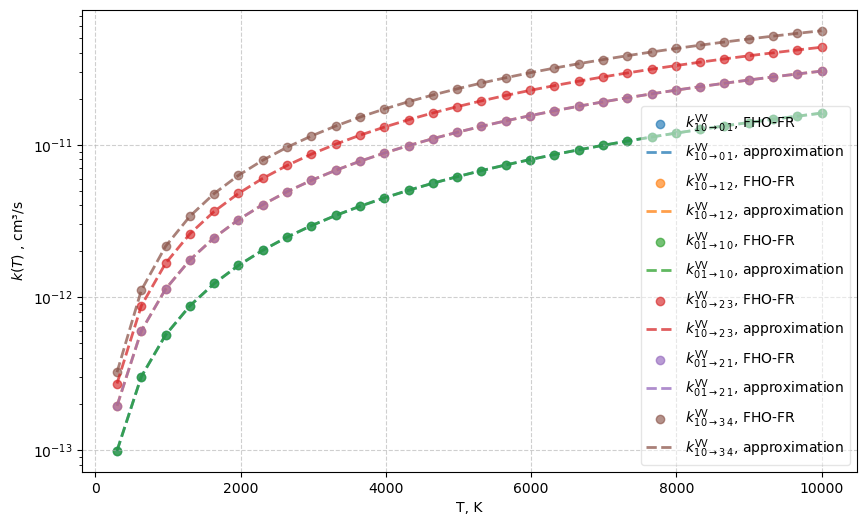

In [2]:
# параметры вашего блока-примера и запуск пайплайна
particle1_name = "O2"
particle2_name = "O2"

v_max = 5
n_points = 30
T_min, T_max = 300.0, 10_000.0

_csv_ds, _csv_reg = run_generation_and_fit(
    particle1_name,
    particle2_name,
    v_max=v_max,
    n_points=n_points,
    T_min=T_min,
    T_max=T_max,
)

Датасет: dataset\N2_N2_dataset.csv (1500 строк)
Регрессия: regression_coefficients\N2_N2_regression_coefs.csv (50 переходов)


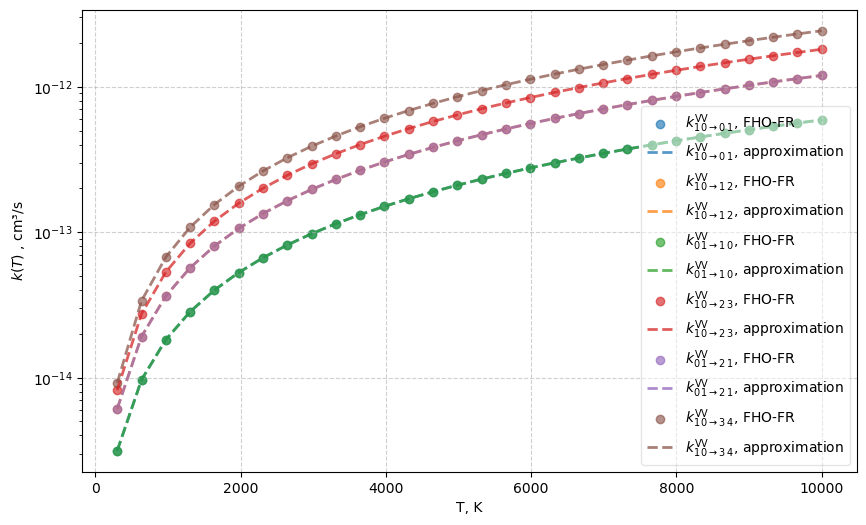

In [2]:
# параметры вашего блока-примера и запуск пайплайна
particle1_name = "N2"
particle2_name = "N2"

v_max = 5
n_points = 30
T_min, T_max = 300.0, 10_000.0

_csv_ds, _csv_reg = run_generation_and_fit(
    particle1_name,
    particle2_name,
    v_max=v_max,
    n_points=n_points,
    T_min=T_min,
    T_max=T_max,
)